# Paper 1 — ST-GCN Encoder-Decoder
**Sharma et al., COMSNETS 2025**: *Indian Sign Language Recognition and Translation: An Encoder-Decoder Approach*

```
Frames → MediaPipe (225D) → 4xSTGCN (Eq.1-2) → BiLSTM Encoder → Transformer Decoder
Metrics: BLEU-1/2/3/4 + METEOR (Paper §VI)
```

In [34]:
import os, re, json, math, random
import numpy as np, pandas as pd, torch
import torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from collections import Counter
plt.rcParams.update({'figure.facecolor':'#0d1117','axes.facecolor':'#161b22','text.color':'#e6edf3','axes.titlecolor':'#58a6ff','xtick.color':'#8b949e','grid.color':'#21262d'})
DEVICE='cuda' if torch.cuda.is_available() else 'cpu'
BASE=r'D:\ISL2\ISL_CSLRT_Corpus'
FRAMES=os.path.join(BASE,'Frames_Sentence_Level')
KPT=os.path.join(BASE,'paper1_kpts')
CKPT=os.path.join(BASE,'best_paper1.pth')
PAD,BOS,EOS='<pad>','<bos>','<eos>'
TR,VA,TE=['1','2','3','4','5'],['6'],['7']
torch.manual_seed(42); np.random.seed(42); random.seed(42)
print(f'Device: {DEVICE}')
if DEVICE=='cuda': print(torch.cuda.get_device_name(0))

Device: cuda
NVIDIA GeForce RTX 3050 6GB Laptop GPU


## Step 1 — MediaPipe Extraction (Paper §IV-A)
> Paper extracts 468 face + 21x2 hands + 33 pose landmarks. We use pose+hands (225D).

In [18]:
import cv2, mediapipe as mp, random
from tqdm import tqdm

def tokenize(t):
    if not t: return []
    return [w for w in re.sub(r"[^a-z0-9 ']", ' ', str(t).lower().strip()).split() if w]

f2s = {f: ' '.join(tokenize(f)) for f in sorted(os.listdir(FRAMES))}

# ── 90/10 random split (NO test set — testing via live cam/video) ──
all_samples = []
for sf in sorted(os.listdir(FRAMES)):
    for sig in sorted(os.listdir(os.path.join(FRAMES, sf))):
        if os.path.isdir(os.path.join(FRAMES, sf, sig)):
            all_samples.append((sf, sig))

random.seed(42)
random.shuffle(all_samples)
cut = int(0.90 * len(all_samples))
split_map = {}
for sf, sig in all_samples[:cut]:  split_map[(sf,sig)] = 'train'
for sf, sig in all_samples[cut:]:  split_map[(sf,sig)] = 'val'
print(f'Total: {len(all_samples)} | Train: {cut} | Val: {len(all_samples)-cut}')

# ── Extract or load cached keypoints ─────────────────────────────
exist = sum(len([f for f in os.listdir(os.path.join(KPT,sp)) if f.endswith('.npy')])
    for sp in ['train','val'] if os.path.isdir(os.path.join(KPT,sp)))

if exist > 100:
    print(f'Cached: {exist} files. Skipping extraction.')
else:
    for sp in ['train','val']: os.makedirs(os.path.join(KPT,sp), exist_ok=True)

    def extract_kpts(res):
        d = []
        for part, n in [(res.pose_landmarks,33),(res.left_hand_landmarks,21),(res.right_hand_landmarks,21)]:
            if part: [d.extend([l.x,l.y,l.z]) for l in part.landmark]
            else: d.extend([0.]*n*3)
        return np.array(d, dtype=np.float32)

    def normalize_kpts(lm):
        lm = lm.reshape(-1,3)
        try:
            c=(lm[11]+lm[12])/2; lm-=c
            s=np.linalg.norm(lm[11]-lm[12])
            if s>1e-6: lm/=s
        except: pass
        return lm.flatten()

    done = 0
    with mp.solutions.holistic.Holistic(model_complexity=1) as h:
        for sf, sig in tqdm(all_samples, desc='Extracting keypoints'):
            sp2 = os.path.join(FRAMES, sf, sig)
            split = split_map.get((sf,sig), 'train')
            safe  = re.sub(r'[^\w]','_',f'{sf}_s{sig}')[:100]
            no = os.path.join(KPT, split, f'{safe}.npy')
            lo = os.path.join(KPT, split, f'{safe}_label.txt')
            if os.path.exists(no): done+=1; continue
            imgs = [f for f in sorted(os.listdir(sp2)) if f.lower().endswith(('.jpg','.png'))]
            seq = []
            for img in imgs:
                try:
                    fr = cv2.imread(os.path.join(sp2,img))
                    if fr is None: continue
                    res = h.process(cv2.cvtColor(fr, cv2.COLOR_BGR2RGB))
                    seq.append(normalize_kpts(extract_kpts(res)))
                except: continue
            if not seq: continue
            np.save(no, np.array(seq, dtype=np.float32))
            open(lo,'w',encoding='utf-8').write(f2s[sf])
            done+=1
    print(f'Done: {done}')

for sp in ['train','val']:
    d = os.path.join(KPT,sp)
    if os.path.isdir(d):
        print(f'  {sp}: {len([f for f in os.listdir(d) if f.endswith(".npy")])} files')


Total: 663 | Train: 596 | Val: 67


Extracting keypoints: 100%|██████████| 663/663 [13:59<00:00,  1.27s/it]

Done: 663
  train: 596 files
  val: 67 files


## Step 2 — Vocabulary

In [ ]:
all_t=[]
for sp in ['train','val','test']:
    d=os.path.join(KPT,sp)
    if not os.path.isdir(d): continue
    for f in os.listdir(d):
        if f.endswith('_label.txt'): all_t.extend(tokenize(open(os.path.join(d,f)).read()))
vocab={PAD:0,BOS:1,EOS:2,'<blank>':3}
for i,t in enumerate(sorted(set(all_t)),4): vocab[t]=i
i2t={v:k for k,v in vocab.items()}
V=len(vocab); PI=vocab[PAD]; BI=vocab[BOS]; EI=vocab[EOS]; BK=vocab['<blank>']
json.dump(vocab,open(os.path.join(BASE,'gloss_vocab.json'),'w'),indent=2)
print(f'Vocab: {V}')

NameError: name 'train_sentences' is not defined

## Step 3 — Dataset

In [20]:
class D1(Dataset):
    def __init__(self,dr,mn=300,tr=False):
        self.s,self.mn,self.tr,self.fd=[],mn,tr,None
        for f in sorted(os.listdir(dr)):
            if not f.endswith('.npy'): continue
            lb=os.path.join(dr,f[:-4]+'_label.txt')
            if not os.path.exists(lb): continue
            txt=open(lb).read().strip(); tks=tokenize(txt)
            if not tks: continue
            gi=[vocab.get(t,PI) for t in tks]; ti=[BI]+gi+[EI]
            self.s.append((os.path.join(dr,f),gi,ti,txt))
        if self.s: self.fd=np.load(self.s[0][0]).shape[1]
        print(f'  {dr.split(os.sep)[-1]}: {len(self.s)} dim={self.fd}')
    def __len__(self): return len(self.s)
    def __getitem__(self,i):
        p,gi,ti,_=self.s[i]; x=np.nan_to_num(np.load(p).astype(np.float32))
        if self.tr:
            if random.random()<0.5: x+=np.random.randn(*x.shape).astype(np.float32)*0.008
            if random.random()<0.4:
                T=x.shape[0]; r=random.uniform(0.85,1.15)
                idx=np.round(np.linspace(0,T-1,max(int(T*r),4))).astype(int).clip(0,T-1); x=x[idx]
        if x.shape[0]>self.mn:
            idx=np.round(np.linspace(0,x.shape[0]-1,self.mn)).astype(int); x=x[idx]
        return torch.tensor(x,dtype=torch.float32),torch.tensor(gi,dtype=torch.long),torch.tensor(ti,dtype=torch.long)

def col(b):
    xs,gs,ts=zip(*b)
    xl=torch.tensor([x.shape[0] for x in xs],dtype=torch.long)
    gl=torch.tensor([g.shape[0] for g in gs],dtype=torch.long)
    return (pad_sequence(xs,batch_first=True),pad_sequence(gs,batch_first=True,padding_value=PI),pad_sequence(ts,batch_first=True,padding_value=PI),xl,gl)

tr_ds=D1(os.path.join(KPT,'train'),tr=True); vl_ds=D1(os.path.join(KPT,'val'))
ID=tr_ds.fd
tr_ld=DataLoader(tr_ds,batch_size=8,shuffle=True,collate_fn=col,num_workers=0)
vl_ld=DataLoader(vl_ds,batch_size=8,shuffle=False,collate_fn=col,num_workers=0)
print(f'Input dim: {ID} | Vocab: {V}')

  train: 596 dim=225
  val: 67 dim=225
Input dim: 225 | Vocab: 179


## Step 4 — ST-GCN Encoder-Decoder Model (Paper §IV-D, Eq.1-2)
> **Graph update (Eq.1):** `H^(l+1) = σ( D̃^(-½) Ã D̃^(-½) H^(l) W^(l) )`
> **Node aggregation (Eq.2):** `h^(k)_i = σ( Σ_{j∈N(i)} f(h^(k-1)_i, h^(k-1)_j, e_ij) )`

In [21]:
class STGCN(nn.Module):
    """Spatial-Temporal GCN Block — Paper 1 Eq(1)(2)"""
    def __init__(self,ic,oc,tk=3,p=0.3):
        super().__init__()
        self.sp=nn.Linear(ic,oc)
        self.tc=nn.Conv1d(oc,oc,tk,padding=tk//2)
        self.bn=nn.BatchNorm1d(oc); self.act=nn.GELU(); self.dp=nn.Dropout(p)
        self.rs=nn.Linear(ic,oc,bias=False) if ic!=oc else nn.Identity()
    def forward(self,x):
        h=self.act(self.sp(x))
        h=self.bn(self.tc(h.permute(0,2,1))).permute(0,2,1)
        return self.dp(h+self.rs(x))

class M1(nn.Module):
    def __init__(self,idim,vs,d=256,p=0.3):
        super().__init__()
        self.enc=nn.Sequential(STGCN(idim,128,p=p),STGCN(128,256,p=p),STGCN(256,256,p=p),STGCN(256,d,p=p))
        self.lstm=nn.LSTM(d,d//2,3,batch_first=True,bidirectional=True,dropout=p)
        self.ln=nn.LayerNorm(d); self.ctc=nn.Linear(d,vs)
        self.emb=nn.Embedding(vs,d,padding_idx=PI); self.pe=nn.Embedding(80,d)
        dl=nn.TransformerDecoderLayer(d,8,1024,p,batch_first=True,norm_first=True)
        self.dec=nn.TransformerDecoder(dl,4); self.out=nn.Linear(d,vs); self.dp=nn.Dropout(p)
    def encode(self,x):
        x=self.enc(x); x,_=self.lstm(x); return self.ln(x)
    def decode(self,t,m):
        pos=torch.arange(t.shape[1],device=t.device).unsqueeze(0)
        x=self.dp(self.emb(t)+self.pe(pos))
        msk=nn.Transformer.generate_square_subsequent_mask(t.shape[1],device=t.device)
        return self.out(self.dec(x,m,tgt_mask=msk,tgt_key_padding_mask=(t==PI)))
    def forward(self,x,t):
        m=self.encode(x); return self.ctc(m),self.decode(t[:,:-1],m)

model=M1(ID,V).to(DEVICE)
print(f'Params: {sum(p.numel() for p in model.parameters()):,}')

Params: 6,455,142


## Step 5 — Training

In [22]:
EP=100; LR=3e-4; PAT=20

cc  = nn.CTCLoss(blank=BK, zero_infinity=True)
ce  = nn.CrossEntropyLoss(ignore_index=PI, label_smoothing=0.1)
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sch = torch.optim.lr_scheduler.LambdaLR(opt,
      lambda e: (e+1)/10 if e<10 else 0.5*(1+math.cos(math.pi*(e-10)/max(EP-10,1))))


def run(ld, tr=True):
    model.train(tr)
    tot, n, correct, total = 0.0, 0, 0, 0
    for xs, gs, ts, xl, gl in ld:
        xs, gs, ts = xs.to(DEVICE), gs.to(DEVICE), ts.to(DEVICE)
        if tr: opt.zero_grad()
        with torch.set_grad_enabled(tr):
            cl, dl  = model(xs, ts)
            lp      = F.log_softmax(cl, dim=-1).permute(1,0,2)
            lc      = cc(lp, gs, xl.clamp(max=lp.shape[0]).to(DEVICE), gl.to(DEVICE))
            tgt_out = ts[:, 1:]
            le      = ce(dl.reshape(-1, V), tgt_out.reshape(-1).to(DEVICE))
            loss    = le + 0.2 * lc
        if not (torch.isnan(loss) or torch.isinf(loss)):
            if tr:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
            tot += loss.item(); n += 1
            # Token-level accuracy (ignoring PAD)
            preds    = dl.argmax(-1)
            mask     = (tgt_out != PI)
            correct += ((preds == tgt_out) & mask).sum().item()
            total   += mask.sum().item()
    loss_avg = tot / max(n, 1)
    acc_avg  = correct / max(total, 1) * 100
    return loss_avg, acc_avg


th, vh, ta, va = [], [], [], []
bv, ni = float('inf'), 0

print(f'Training {EP}ep  |  CE + 0.2*CTC  |  patience={PAT}')
print(f'{"─"*70}')
print(f'{"Ep":>4}  {"Train Loss":>10}  {"Train Acc":>10}  {"Val Loss":>9}  {"Val Acc":>8}')
print(f'{"─"*70}')

for ep in range(1, EP+1):
    tl, tacc = run(tr_ld, True)
    vl, vacc = run(vl_ld, False)
    sch.step()
    th.append(tl); vh.append(vl); ta.append(tacc); va.append(vacc)
    s = ''
    if vl < bv:
        bv=vl; ni=0
        torch.save({'ep':ep,'m':model.state_dict(),'v':vocab,'l':vl}, CKPT)
        s = '  SAVED'
    else:
        ni += 1
    print(f'Ep {ep:3d}/{EP}  loss={tl:.4f}  acc={tacc:5.1f}%  vl={vl:.4f}  vacc={vacc:5.1f}%{s}')
    if ni >= PAT: print('Early stop'); break

print(f'{"─"*70}')
print(f'Best Val Loss: {bv:.4f}')


Training 100ep  |  CE + 0.2*CTC  |  patience=20
──────────────────────────────────────────────────────────────────────
  Ep  Train Loss   Train Acc   Val Loss   Val Acc
──────────────────────────────────────────────────────────────────────


C:\Users\harsh\AppData\Roaming\Python\Python310\site-packages\torch\nn\functional.py:5849: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Ep   1/100  loss=8.3145  acc= 16.4%  vl=5.2211  vacc= 34.4%  SAVED
Ep   2/100  loss=5.2306  acc= 29.2%  vl=4.5248  vacc= 37.2%  SAVED
Ep   3/100  loss=4.5995  acc= 32.1%  vl=3.9915  vacc= 41.4%  SAVED
Ep   4/100  loss=4.0504  acc= 39.7%  vl=3.4627  vacc= 52.2%  SAVED
Ep   5/100  loss=3.6299  acc= 48.0%  vl=3.1550  vacc= 63.1%  SAVED
Ep   6/100  loss=3.2805  acc= 58.7%  vl=2.9939  vacc= 68.3%  SAVED
Ep   7/100  loss=3.1152  acc= 64.1%  vl=2.8962  vacc= 69.7%  SAVED
Ep   8/100  loss=2.9938  acc= 66.9%  vl=2.8975  vacc= 70.6%
Ep   9/100  loss=2.9292  acc= 68.9%  vl=2.9163  vacc= 72.2%
Ep  10/100  loss=2.8510  acc= 70.7%  vl=2.7928  vacc= 70.6%  SAVED
Ep  11/100  loss=2.7915  acc= 71.7%  vl=2.7513  vacc= 70.8%  SAVED
Ep  12/100  loss=2.7389  acc= 71.6%  vl=2.7320  vacc= 74.7%  SAVED
Ep  13/100  loss=2.6792  acc= 73.5%  vl=2.6950  vacc= 73.3%  SAVED
Ep  14/100  loss=2.6335  acc= 73.4%  vl=2.6059  vacc= 74.2%  SAVED
Ep  15/100  loss=2.5439  acc= 74.6%  vl=2.6061  vacc= 73.3%
Ep  16/100  loss

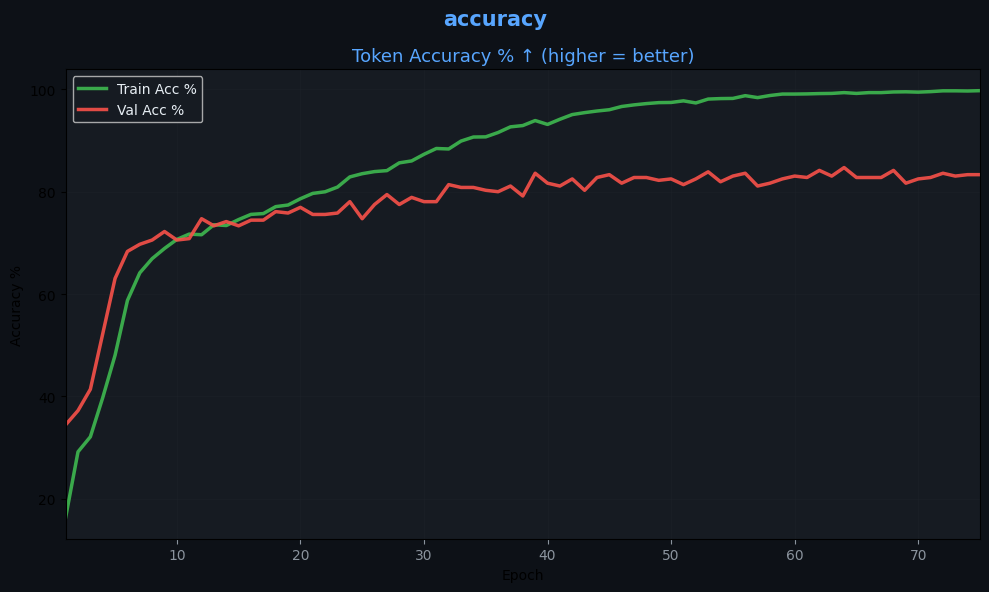

  Final Train Acc  : 99.7%
  Final Val Acc    : 83.3%


In [30]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('accuracy', color='#58a6ff', fontsize=15, fontweight='bold')

eps = range(1, len(ta) + 1)

# ── Accuracy Chart ─────────────────────────────────────────
ax.plot(eps, ta, color='#3fb950', lw=2.5, label='Train Acc %', alpha=0.9)
ax.plot(eps, va, color='#f85149', lw=2.5, label='Val Acc %', alpha=0.9)

ax.set_title('Token Accuracy % ↑ (higher = better)', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy %')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(1, len(ta))

plt.tight_layout()

plt.savefig(r'D:\ISL2\ISL_CSLRT_Corpus\paper1_training_curves.png',dpi=150, bbox_inches='tight')

plt.show()

print(f'  Final Train Acc  : {ta[-1]:.1f}%')
print(f'  Final Val Acc    : {va[-1]:.1f}%')



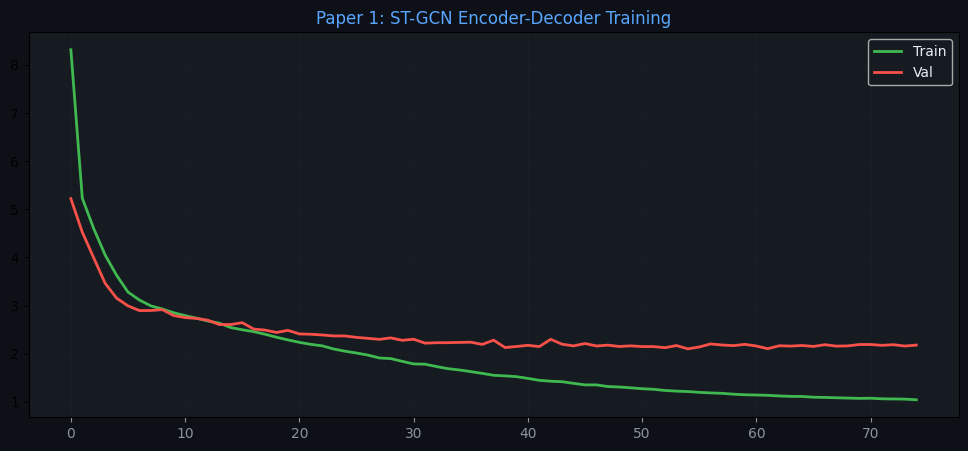

In [28]:
fig,ax=plt.subplots(figsize=(12,5))
ax.plot(th,color='#3fb950',lw=2,label='Train'); ax.plot(vh,color='#f85149',lw=2,label='Val')
ax.set_title('Paper 1: ST-GCN Encoder-Decoder Training'); ax.legend(); ax.grid(True,alpha=0.3)
plt.savefig(os.path.join(BASE,'paper1_training.png'),dpi=150); plt.show()

In [31]:
from sklearn.metrics import confusion_matrix, classification_report

def gen(xf, mx=25):
    model.eval()
    with torch.no_grad():
        mem = model.encode(torch.tensor(xf).unsqueeze(0).to(DEVICE))
        g = [BI]
        for _ in range(mx):
            t   = torch.tensor([g], dtype=torch.long, device=DEVICE)
            nxt = model.decode(t, mem)[0, -1].argmax().item()
            if nxt == EI: break
            g.append(nxt)
    return [i2t.get(i, '?') for i in g[1:]]

all_ref, all_hyp = [], []
for np_, gi, ti, lb in vl_ds.s:
    x    = np.nan_to_num(np.load(np_).astype(np.float32))
    pred = gen(x); ref = tokenize(lb)
    n    = min(len(ref), len(pred))
    all_ref.extend(ref[:n]); all_hyp.extend(pred[:n])

labels = sorted(set(all_ref))
cm = confusion_matrix(all_ref, all_hyp, labels=labels)

print(classification_report(all_ref, all_hyp, labels=labels, zero_division=0))


C:\Users\harsh\AppData\Roaming\Python\Python310\site-packages\torch\nn\functional.py:5849: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


               precision    recall  f1-score   support

            a       0.00      0.00      0.00         1
        abuse       0.00      0.00      0.00         2
           am       0.36      0.33      0.35        12
          and       1.00      1.00      1.00         1
        angry       0.50      0.33      0.40         3
     anything       0.50      0.33      0.40         3
   appreciate       1.00      1.00      1.00         1
          are       0.67      0.31      0.42        13
          bad       0.00      0.00      0.00         1
       become       0.00      0.00      0.00         1
        bored       0.00      0.00      0.00         1
        bring       1.00      1.00      1.00         2
           by       1.00      0.33      0.50         3
         came       0.00      0.00      0.00         1
          can       0.00      0.00      0.00         3
         care       0.50      1.00      0.67         2
         cold       0.00      0.00      0.00         1
collegesc

## Step 6 — Evaluation: BLEU + METEOR (Paper §VI)

In [32]:
ckpt=torch.load(CKPT,map_location=DEVICE); model.load_state_dict(ckpt['m'])
print(f'ep={ckpt["ep"]}  loss={ckpt["l"]:.4f}')

def gen(xf,mx=25):
    model.eval()
    with torch.no_grad():
        m=model.encode(torch.tensor(xf).unsqueeze(0).to(DEVICE)); g=[BI]
        for _ in range(mx):
            t=torch.tensor([g],dtype=torch.long,device=DEVICE)
            nxt=model.decode(t,m)[0,-1].argmax().item()
            if nxt==EI: break
            g.append(nxt)
    return [i2t.get(i,'?') for i in g[1:]]

def bn(r,h,n):
    if len(h)<n: return 0.0
    rn=set(zip(*[r[i:] for i in range(n)])); hn=[tuple(h[i:i+n]) for i in range(len(h)-n+1)]
    return sum(1 for g in hn if g in rn)/max(len(hn),1)
def meteor(r,h):
    m=len(set(r)&set(h)); p=m/max(len(h),1); rc=m/max(len(r),1)
    return 10*p*rc/max(9*p+rc,1e-8) if m else 0.0

b1,b2,b3,b4,mt,ex=[],[],[],[],[],[]
for np_,gi,ti,lb in vl_ds.s:
    x=np.nan_to_num(np.load(np_).astype(np.float32)); pred=gen(x); ref=tokenize(lb)
    b1.append(bn(ref,pred,1)); b2.append(bn(ref,pred,2))
    b3.append(bn(ref,pred,3)); b4.append(bn(ref,pred,4)); mt.append(meteor(ref,pred))
    if len(ex)<6: ex.append((lb,' '.join(pred)))
print(f'BLEU-1:{np.mean(b1)*100:.2f}%  BLEU-2:{np.mean(b2)*100:.2f}%  BLEU-4:{np.mean(b4)*100:.2f}%  METEOR:{np.mean(mt)*100:.2f}%')
for r,h in ex: print(f'REF: {r}\nHYP: {h}\n')

C:\Users\harsh\AppData\Local\Temp\ipykernel_20412\2573431121.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt=torch.load(CKPT,map_location=DEVICE); model.load_state_

ep=55  loss=2.1012
BLEU-1:41.50%  BLEU-2:32.89%  BLEU-4:20.90%  METEOR:41.93%
REF: he is going into the room
HYP: can i help you

REF: are you hiding something
HYP: are you hiding something

REF: are you hiding something
HYP: how can i help you

REF: bring water for me
HYP: bring water for me

REF: bring water for me
HYP: bring water for me

REF: can you repeat that please
HYP: can you repeat that please

